In [ ]:
# =========================================================
# STEP 1 — Load images, preprocess, normalize, and split
# =========================================================
import os, random, numpy as np, cv2, tensorflow as tf, matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Set reproducible seeds
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Mount Google Drive (grant permission)
drive.mount('/content/drive')

# Path inside Drive (adjust folder names as needed)
dataset_root = '/content/drive/MyDrive/PlantDoc-Dataset'
train_dir = f'{dataset_root}/train'
test_dir  = f'{dataset_root}/test'

# ---------------------------------------------------------
# Function to load PlantDoc data
# ---------------------------------------------------------
def load_plantdoc_data(data_dir, img_size=(224, 224)):
    X, y = [], []
    class_names = sorted([d for d in os.listdir(data_dir)
                          if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {cls: i for i, cls in enumerate(class_names)}
    for cls in class_names:
        cls_dir = os.path.join(data_dir, cls)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            X.append(img)
            y.append(class_to_idx[cls])
    return np.array(X, np.float32), np.array(y, np.int32), class_names

# Load data
X_train, y_train, class_names = load_plantdoc_data(train_dir)
X_test,  y_test,  _ = load_plantdoc_data(test_dir)
num_classes = len(class_names)

# Normalize pixel values
X_train, X_test = X_train / 255.0, X_test / 255.0

# Split into train‑val (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

# One‑hot encode
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Classes:", class_names)

Mounted at /content/drive
Train: (1852, 224, 224, 3), Val: (464, 224, 224, 3), Test: (236, 224, 224, 3)
Classes: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Raspberry leaf', 'Soyabean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'grape leaf', 'grape leaf black rot']


In [ ]:
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras import layers, models, optimizers, regularizers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

base_model = EfficientNetV2L(
    include_top=False, weights="imagenet", input_shape=(224,224,3)
)
base_model.trainable = False  # start frozen

inputs = tf.keras.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

optimizer = optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 7, 7, 1280)     │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,421,691 (451.74 MB)

 Trainable params: 672,283 (2.56 MB)

 Non-trainable params: 117,749,408 (449.18 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 95s 805ms/step - accuracy: 0.0345 - loss: 4.2489 - val_accuracy: 0.0474 - val_loss: 3.3585 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 539ms/step - accuracy: 0.0505 - loss: 4.1612 - val_accuracy: 0.0496 - val_loss: 3.3565 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 543ms/step - accuracy: 0.0595 - loss: 4.0322 - val_accuracy: 0.0603 - val_loss: 3.3588 - learning_rate: 0.0010
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 555ms/step - accuracy: 0.0469 - loss: 3.9223 - val_accuracy: 0.0625 - val_loss: 3.3632 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 550ms/step - accuracy: 0.0595 - loss: 3.8182 - val_accuracy: 0.0668 - val_loss: 3.3629 - learning_rate: 0.0010
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 550ms/step - accuracy: 0.0728 - loss: 3.6289 - val_accuracy: 0.0690 - val_loss: 3.3616 - learning_rate: 2.0000e-04
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 33s 563ms/step - accuracy: 0.0742 - loss

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False  # unfreeze last ~50 layers

model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

fine_tune_history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 102s 883ms/step - accuracy: 0.0562 - loss: 3.5831 - val_accuracy: 0.0453 - val_loss: 3.3599 - learning_rate: 1.0000e-05
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 646ms/step - accuracy: 0.0557 - loss: 3.4556 - val_accuracy: 0.0603 - val_loss: 3.2992 - learning_rate: 1.0000e-05
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 636ms/step - accuracy: 0.0717 - loss: 3.4125 - val_accuracy: 0.0668 - val_loss: 3.2862 - learning_rate: 1.0000e-05
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 642ms/step - accuracy: 0.0675 - loss: 3.3741 - val_accuracy: 0.0776 - val_loss: 3.2780 - learning_rate: 1.0000e-05
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 639ms/step - accuracy: 0.0784 - loss: 3.3460 - val_accuracy: 0.0884 - val_loss: 3.2626 - learning_rate: 1.0000e-05
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 641ms/step - accuracy: 0.0865 - loss: 3.3401 - val_accuracy: 0.1099 - val_loss: 3.2564 - learning_rate: 1.0000e-05
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 640ms/step - ac

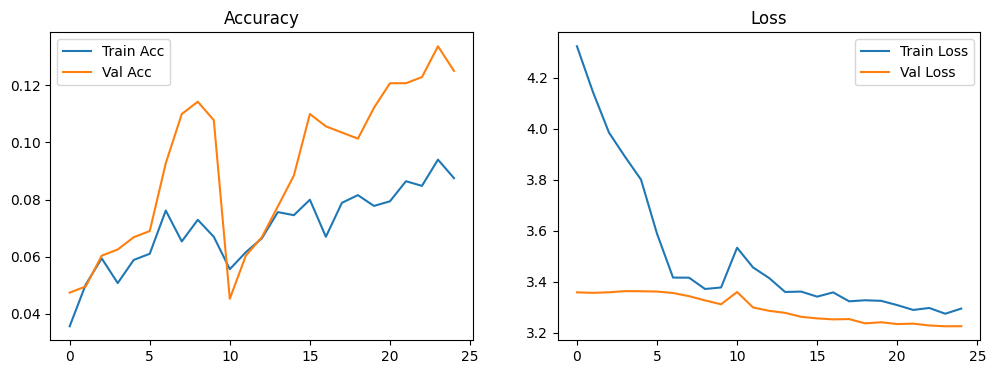

In [ ]:
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(acc, label='Train Acc'); plt.plot(val_acc, label='Val Acc')
plt.legend(); plt.title("Accuracy")
plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss'); plt.plot(val_loss, label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()

Final Test Accuracy: 0.0975
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step


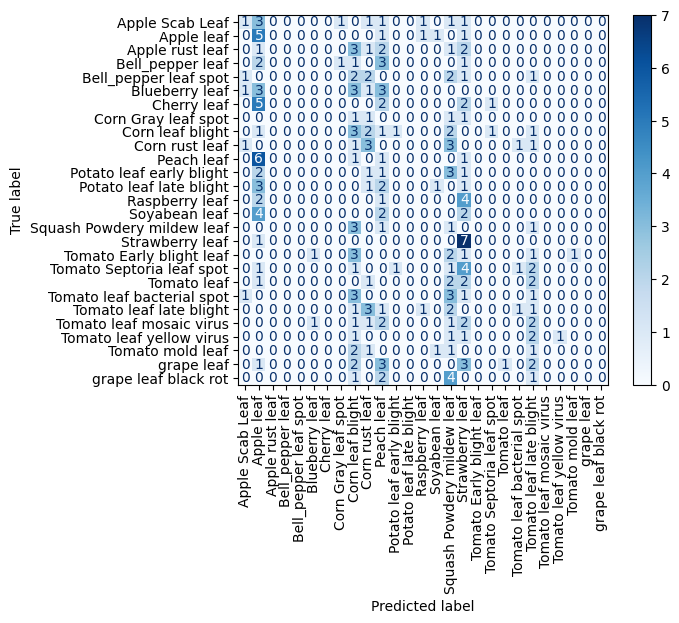


Classification Report:

                            precision    recall  f1-score   support

           Apple Scab Leaf       0.20      0.10      0.13        10
                Apple leaf       0.12      0.56      0.20         9
           Apple rust leaf       0.00      0.00      0.00        10
          Bell_pepper leaf       0.00      0.00      0.00         8
     Bell_pepper leaf spot       0.00      0.00      0.00         9
            Blueberry leaf       0.00      0.00      0.00        11
               Cherry leaf       0.00      0.00      0.00        10
       Corn Gray leaf spot       0.00      0.00      0.00         4
          Corn leaf blight       0.09      0.25      0.13        12
            Corn rust leaf       0.16      0.30      0.21        10
                Peach leaf       0.03      0.11      0.05         9
  Potato leaf early blight       0.00      0.00      0.00         8
   Potato leaf late blight       0.00      0.00      0.00         8
            Raspberry 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=90, cmap="Blues")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
save_path = '/content/drive/MyDrive/EfficientNet_PlantDoc_FineTuned.h5'
model.save(save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/EfficientNet_PlantDoc_FineTuned.h5
